# 01 - Intro and Plotting, Ingesting MOM6 output with `xgcm`

Open a MOM6 regional run, build an `xgcm.Grid`, move fields between C-grid positions, derive vorticity and density, then map and animate the result.

## Setup

History files are opened directly in the cells below; only the scientific operations are wrapped in functions.

In [ ]:
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}
import glob
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
import matplotlib.ticker as mticker
import xgcm

from mom6_tools.wright_eos import wright_eos, alpha_wright_eos, beta_wright_eos
from mom6_tools.jobqueue import get_cluster

xr.set_options(keep_attrs=True)

FIGDIR = Path("diagnostic_figures")
FIGDIR.mkdir(exist_ok=True)

### Start a Dask Cluster/Client
Dask is a parallel computation library for Python that lets us initialize multiple workers to act as parallel processors. There are two options for creating a dask cluster:
- PBSCluster: This submits new PBS jobs for each worker, running separate jobs on Casper/Derecho for each worker.
- LocalCluster: If you are running this notebook on an existing PBS job with enough resources, it can access those resources directly.

In [ ]:
DASK = "PBSCluster" # or LocalCluster (works with SLURMCluster on other systems)

N_WORKERS = 4

ACCOUNT = "P93300012" # charge worker jobs here, defaults to PROJECT and PBS_ACCOUNT env variables in bash
QUEUE = "casper" # or "derecho"
INTERFACE = 'ext' # or "ib0" for derecho

# Following are resources for each worker
# Total resources are N_WORKERS * resource (e.g. N_WORKERS * MEMORY).
MEMORY = "20GB"
CORES = 4
PROCESSES = 1
WALLTIME = "03:00:00"

success, client, cluster = get_cluster(nw=N_WORKERS, cluster_class=DASK, account=ACCOUNT, queue=QUEUE, walltime=WALLTIME, memory=MEMORY, processes=PROCESSES, cores = CORES, interface=INTERFACE, log_directory="logs",)

In [ ]:
client

## Case Selection

In [ ]:
# --- Case configuration ---
CASE = dict(
        casename="small_alaska",
        hist="/glade/derecho/scratch/manishrv/archive/small_alaska/ocn/hist",
        input_dir="/glade/u/home/manishrv/scratch/croc_input/small_alaska/ocn",
        date_range=["2020-01-01", "2020-01-08"],
        length="demo" # or "full", if you have more than 1 month of output. Otherwise native and z files will be filled values
    )

HIST = CASE["hist"]
INPUT_DIR = CASE["input_dir"]
DATE_RANGE = CASE["date_range"]
FILE_PATTERN = f"{HIST}/{CASE['casename']}.mom6"
MONTH = DATE_RANGE[0][:7]   # the monthly native/z file DATE_RANGE starts in

## Other Paths and Settings
GLORYS_ROOT = "/gdex/data/d010049"

# MOM6/FMS counts days with proleptic-Gregorian rules but labels the axis
# `calendar = "gregorian"`, which CF defines as the mixed Julian/Gregorian
# calendar. Open history files with decode_times=False and pass them to decode_mom6_time().
# If you are running with 'noleap', use `MOM6_CALENDAR = "noleap"`
MOM6_CALENDAR = "proleptic_gregorian"

print(f"{CASE['casename']}: {FILE_PATTERN}.h.*.nc")

### Relevant Files
- STATIC - `casename.mom6.h.static.nc`: contains real lat/lon coords, grid information, coriolis parameter
- GEOM - `casename.mom6.h.ocean_geometry.nc`: a lot of similar info to STATIC, includes bathymetry

The provided geolat/geolon coords give physical lat/lon adjusted across the grid for the most accurate plotting and geolocating. Default xh/yh coords are the nominal lat/lon which are best used as indices and temporary coords before rigorous scientific plotting/analysis.

In [ ]:
# --- Grid files ---
# The static file carries the land masks, cell areas and Coriolis parameter.
STATIC = xr.open_dataset(f"{FILE_PATTERN}.h.static.nc", decode_times=False).squeeze(drop=True)

# Rename geometry coords to the history-file names.
GEOM = (xr.open_dataset(f"{FILE_PATTERN}.h.ocean_geometry.nc")
          .rename_dims({"lath": "yh", "lonh": "xh", "latq": "yq", "lonq": "xq"})
          .drop_vars(["lath", "lonh", "latq", "lonq"]))

# Attach these to any history DATASET with `ds = ds.assign_coords(COORDS)`
# This streamlines plotting and xgcm grid operations, which expect the geometry coords to be present.
COORDS = {name: GEOM[name] for name in
          ("geolon", "geolat", "geolonu", "geolatu",
           "geolonv", "geolatv", "geolonb", "geolatb")}

# Example: STATIC now stores geolon/geolat as data variables (psst it already had them, just a demo)
STATIC = STATIC.assign_coords(COORDS)

print(dict(STATIC.sizes))
print("lon {:.2f} .. {:.2f}   lat {:.2f} .. {:.2f}".format(
    float(GEOM.geolon.min()), float(GEOM.geolon.max()),
    float(GEOM.geolat.min()), float(GEOM.geolat.max())))

### Formatting Plots
For efficiency in these notebooks, we provide some standard plot settings and information. This lets us quickly use the implicit plotting capapbilities of xarray (i.e. dataarray.plot(kwargs**)).

In [ ]:
# --- Standard plotting keywords ---
# Everything is plotted with xarray's own `.plot()`; these dicts just supply the
# coordinates and the transform so everything is standardized and pretty!

SUBPLOT = {"projection": ccrs.Robinson(central_longitude=float(GEOM.geolon.mean()))}
LAND = cfeature.LAND.with_scale("50m")

_aspect = float(GEOM.geolat.max() - GEOM.geolat.min()) / float(GEOM.geolon.max() - GEOM.geolon.min())
PANEL = np.array([18.0, round(18.0 * _aspect)])

# Lat lon gridlines for all plots. Use `ax.gridlines(**GRID)` to apply.
nticks = 7
GRID = dict(
      draw_labels=["bottom", "left"],
      xlocs=mticker.MultipleLocator(np.round(np.abs((GEOM.geolon.max().values - GEOM.geolon.min().values) / nticks), 1)),
      ylocs=mticker.MultipleLocator(np.round(np.abs((GEOM.geolat.max().values - GEOM.geolat.min().values) / nticks), 1)),
      linewidth=0.5, color="0.5", alpha=0.5,
  )

# Fast map for plotting MOM6 fields. Use `ds.plot(**MAP[grid])` where grid is one of "h", "u", "v", or "q".
# h - tracers, q - corners, u - u-velocity, v - v-velocity
MAP = {
    "h": dict(x="geolon",  y="geolat",  transform=ccrs.PlateCarree()),
    "u": dict(x="geolonu", y="geolatu", transform=ccrs.PlateCarree()),
    "v": dict(x="geolonv", y="geolatv", transform=ccrs.PlateCarree()),
    "q": dict(x="geolonb", y="geolatb", transform=ccrs.PlateCarree()),
}

# add-ons to spread over a `.plot()` call
DIFF = dict(cmap="cmo.balance", center=0, robust=True)   # diverging / difference
SECTION = dict(yincrease=False)                          # depth down the y axis

# SECTION only sets the axis direction, so it combines with anything:
#     da.plot(ax=ax, **SECTION, **DIFF)              a difference section
#     da.plot(ax=ax, **SECTION, robust=True)         clip the colour range
# Add robust=True deliberately -- on a shallow shelf it can clip a real deep
# temperature core out of the picture.

### xgcm grid and metrics
We use the xgcm for efficient handling of the Arakawa C-grid geometry. We provide information about which corrdinates correspond to tracer (center) points velocity (face) points. We also provide grid metrics from the geometry file into the xgcm grid and the relevant datasets.
Metrics give grid cell spacing and areas for different operations (e.g. area-weighted interpolation and grid size based difference).

The coordinates and metrics in the xgcm grid need to be present in the history file.

[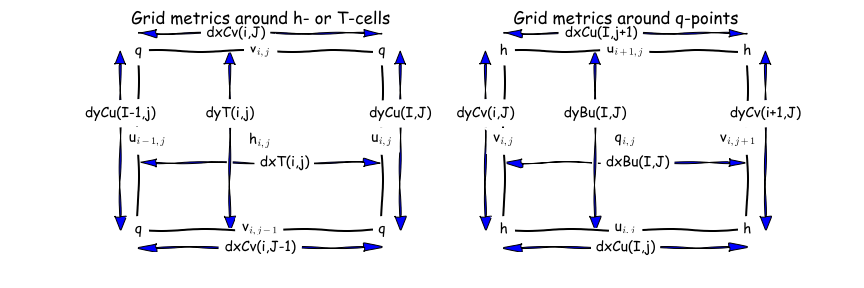](https://mom6.readthedocs.io/en/dev-gfdl/_images/Grid_metrics.png)

In [ ]:
# --- xgcm grid and derived quantities ---

XGCM_COORDS = {
    "X": {"center": "xh", "outer": "xq"},
    "Y": {"center": "yh", "outer": "yq"},
    "Z": {"center": "zl", "outer": "zi"},
}

def make_grid(ds, geom, with_metrics=True, xgcm_coords=XGCM_COORDS):
    """Build an xgcm.Grid for a MOM6 regional dataset, as (grid, ds_with_metrics).

    Metrics come from the ocean_geometry file `geom` so that grid.diff /
    grid.interp / grid.derivative / grid.integrate know the cell spacings.
    """
    coords = {ax: pos for ax, pos in xgcm_coords.items() if pos["center"] in ds.dims} # flexible for 3D/2D data
    obj, metrics = ds, None
    
    if with_metrics:
        for v in ("dxCu", "dyCu", "dxCv", "dyCv", "dxT", "dyT",
                  "dxBu", "dyBu", "Ah", "Aq"):
            if v in geom and set(geom[v].dims) <= set(ds.dims):
                obj = obj.assign_coords({v: geom[v]})
        metrics = {
            ("X",): [v for v in ("dxT", "dxCu", "dxCv", "dxBu") if v in obj.coords],
            ("Y",): [v for v in ("dyT", "dyCu", "dyCv", "dyBu") if v in obj.coords],
            ("X", "Y"): [v for v in ("Ah", "Aq") if v in obj.coords],
        }
        metrics = {k: v for k, v in metrics.items() if v}
        
    grid = xgcm.Grid(obj, coords=coords, metrics=metrics, padding="extend",
                autoparse_metadata=False)
    
    return grid, obj

def decode_mom6_time(ds, calendar="proleptic_gregorian"):
    """Decode MOM6 time axes, correcting the calendar that MOM6 mislabels.
    """
    ds = ds.copy()
    for v in ds.variables:
        attrs = dict(ds[v].attrs)
        if "since" in str(attrs.get("units", "")):
            attrs["calendar"] = calendar
            ds[v].attrs = attrs
    return xr.decode_cf(ds)

def relative_vorticity(grid, ds, u="uo", v="vo"):
    """Relative vorticity at the corner (q) point [s-1], the MOM6 discretisation:

        zeta = ( d/dx (v * dyCv) - d/dy (u * dxCu) ) / Aq
    """
    dvdx = grid.diff(ds[v] * ds["dyCv"], "X", padding="fill", fill_value=0.0)
    dudy = grid.diff(ds[u] * ds["dxCu"], "Y", padding="fill", fill_value=0.0)
    zeta = (dvdx - dudy) / ds["Aq"]
    zeta.name = "zeta"
    zeta.attrs = {"long_name": "Relative vorticity", "units": "s-1"}
    return zeta

def density(T, S, p=0.0):
    """In-situ density [kg m-3] from the MOM6 Wright (1997) EOS.

    T in degC, S in psu, p in Pa.  T and S must be xarray objects (wrap a T/S
    mesh in xr.DataArray when contouring sigma0).  Uses mom6_tools.wright_eos.
    """
    rho = xr.apply_ufunc(wright_eos, T, S, p, dask="allowed", keep_attrs=False)
    rho.name = "rho"
    rho.attrs = {"long_name": "In-situ density (Wright 1997 EOS)", "units": "kg m-3"}
    return rho

def sigma0(T, S):
    """Potential density anomaly referenced to 0 dbar [kg m-3]."""
    s = density(T, S, 0.0) - 1000.0
    s.name = "sigma0"
    s.attrs = {"long_name": "Potential density anomaly (sigma-0)", "units": "kg m-3"}
    return s


In [ ]:
# --- GIF helper ---
def save_gif(frame_paths, out_path, duration=350, loop=0, clean = False):
    """Stitch saved PNG frames into an animated GIF with Pillow.
    """
    from PIL import Image

    frames = [Image.open(p).convert("P", palette=Image.ADAPTIVE)
              for p in frame_paths]
    out_path = Path(out_path)
    frames[0].save(out_path, save_all=True, append_images=frames[1:],
                   duration=duration, loop=loop, optimize=True)
    
    if clean:
        for p in frame_paths:
            os.remove(p)
    
    return out_path


def save_field_gif(field, frames_dir, out_path, subplot_kw, map_kw, figsize, land=None,
                   gridlines_kw=None, cmap="cmo.thermal", coastlines="10m",
                   title=None, dpi=90, duration=100, loop=0, clean=False):
    """One PNG per time record of `field`, stitched into an animated GIF.

    `field` is a map-shaped DataArray with a `time` dim, already masked and
    loaded.  `subplot_kw`, `map_kw`, `figsize`, `land` and `gridlines_kw` are the
    notebook's SUBPLOT, MAP[...], PANEL, LAND and GRID.

    The colour range is taken once over the whole field and the figure size is
    fixed, so every frame comes out on the same scale and the same size.  Frames
    are written beside `out_path`, and `clean` removes them once stitched.
    """
    out_path = Path(out_path)
    vmin, vmax = float(field.min()), float(field.max())
    label = field.name if title is None else title

    frames = []
    for i in range(field.sizes["time"]):
        fig, ax = plt.subplots(figsize=figsize, subplot_kw=subplot_kw)
        field.isel(time=i).plot(ax=ax, **map_kw, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.coastlines(coastlines)
        if land is not None:
            ax.add_feature(land, facecolor="0.85")
        if gridlines_kw is not None:
            ax.gridlines(**gridlines_kw)
        fig.suptitle(f"{label}   {str(field.time.values[i])[:10]}")
        p = out_path.stem / Path(frames_dir) / f"frame_{i:03d}.png"
        fig.savefig(p, dpi=dpi)
        plt.close(fig)
        frames.append(p)

    return save_gif(frames, out_path, duration=duration, loop=loop, clean=clean)


## 1. The grid

`static` carries the land masks, areas and Coriolis; `ocean_geometry` carries the spacings and the 2-D longitudes/latitudes for each position.

In [ ]:
# --- What the two grid files carry ---
print("static:", dict(STATIC.sizes))
for label, name in [("h  (tracer)", "geolon"), ("u  (Cu face)", "geolonu"),
                    ("v  (Cv face)", "geolonv"), ("q  (Bu corner)", "geolonb")]:
    print(f"  {label:16s} dims={GEOM[name].dims}  shape={GEOM[name].shape}")

print("\nspacings in ocean_geometry:",
      [v for v in ("dxT", "dyT", "dxCu", "dyCu", "dxCv", "dyCv", "Ah", "Aq")
       if v in GEOM])
print("masks in static:  ",
      [v for v in ("wet", "wet_u", "wet_v", "wet_c") if v in STATIC])

In [ ]:
# --- Bathymetry ---
deptho = STATIC["deptho"].where(STATIC.wet)

fig, ax = plt.subplots(figsize=PANEL, subplot_kw=SUBPLOT)
deptho.plot(**MAP["h"], ax=ax,  cmap=cmo.deep)
ax.coastlines("50m")
ax.add_feature(LAND, facecolor="0.85")
gl = ax.gridlines(**GRID)
fig.suptitle(f"{CASE['casename']}: bathymetry")
fig.savefig(FIGDIR / "01_bathymetry.png", dpi=200)

## 2. The xgcm grid and C-grid interpolation

`grid.interp` moves `SSU` and `SSV` off their cell faces onto the tracer point so they can be combined into a speed.

In [ ]:
from mom6_tools.regional_m6toolbox import decode_mom6_time

# --- Surface stream (daily records) ---
sfc = xr.open_mfdataset(f"{FILE_PATTERN}.h.sfc.*.nc", decode_times=False,
                      chunks={"time": 1})
sfc = decode_mom6_time(sfc, calendar=MOM6_CALENDAR).sel(time=slice(*DATE_RANGE))     # MOM6 mislabels its calendar; fix then decode
sfc = sfc.assign_coords(COORDS)

print(dict(sfc.sizes))
print(str(sfc.time.values[0])[:10], "->", str(sfc.time.values[-1])[:10],
      f"({sfc.sizes['time']} records)")

In [ ]:
from mom6_tools.regional_m6toolbox import make_grid

# --- u and v from the cell faces to the tracer point ---
grid, sfc_metrics = make_grid(sfc, GEOM)
print(grid)

# Interpolate the surface u and v from the cell faces to the tracer point (xq,yq) -> (xh,yh)
u_t = grid.interp(sfc_metrics["SSU"].where(STATIC.wet_u), "X")   # xq (outer) -> xh
v_t = grid.interp(sfc_metrics["SSV"].where(STATIC.wet_v), "Y")   # yq (outer) -> yh

print("\nSSU", sfc["SSU"].dims, sfc["SSU"].shape, "->", u_t.dims, u_t.shape)
print("SSV", sfc["SSV"].dims, sfc["SSV"].shape, "->", v_t.dims, v_t.shape)

In [ ]:
# --- The three staggered fields.  ax.set_title does not render on a Cartopy
# --- axis with labelled gridlines, so label panels with ax.text.
SSH_VAR = next(v for v in ("zos", "SSH", "ssh") if v in sfc) # sometimesinconsistent
print("model SSH variable:", SSH_VAR)

time_idx = 0
date = str(sfc.time.values[time_idx])[:10]
panels = [(sfc["SSU"].isel(time=time_idx).where(STATIC.wet_u), "u", "cmo.balance"),
          (sfc["SSV"].isel(time=time_idx).where(STATIC.wet_v), "v", "cmo.balance"),
          (sfc['speed'].isel(time=time_idx), "h", "cmo.speed"), 
          (sfc['tos'].isel(time=time_idx), "h", "cmo.thermal"),
          (sfc['sos'].isel(time=time_idx), "h", "cmo.haline"),
          (sfc[SSH_VAR].isel(time=time_idx), "h", "cmo.balance"),
          (sfc['mlotst'].isel(time=time_idx), "h", "cmo.deep"),]

fig, axs = plt.subplots(len(panels), 1, figsize=(PANEL[0], PANEL[1] * len(panels)),
                        subplot_kw=SUBPLOT)
for ax, (da, pos, cmap) in zip(axs, panels):
    kw =dict(cmap=cmap, robust=True)
    da.plot(ax=ax, **MAP[pos], **kw)
    ax.coastlines("50m")
    ax.add_feature(LAND, facecolor="0.85")
    gl = ax.gridlines(**GRID)
    # Set the tick formatter for the colorbar
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
fig.savefig(FIGDIR / "01_plot_vars.png", dpi=250)

## 3. Relative vorticity

Vorticity lands on the corner (q) point, where `Coriolis` already lives, so the ratio needs no further interpolation.

In [ ]:
from mom6_tools.regional_m6toolbox import relative_vorticity

# --- zeta at the corner point, and zeta / f ---
time_idx = 0
zeta = (relative_vorticity(grid, sfc_metrics, u="SSU", v="SSV")
        .isel(time=time_idx).where(STATIC.wet_c))

In [ ]:
# --- Corner-point fields plot with MAP["q"] ---
fig, ax = plt.subplots(figsize=PANEL, subplot_kw=SUBPLOT)
zeta.plot(ax=ax, **MAP["q"], **dict(cmap="cmo.curl", center=0, robust=True))
ax.coastlines("50m")
ax.add_feature(LAND, facecolor="0.85")
gl = ax.gridlines(**GRID)
fig.savefig(FIGDIR / "01_vorticity.png", dpi=120)

## 4. Density from the Wright (1997) equation of state

`sigma0` calls the same EOS mom6-tools uses (Wright 1997). The surface stream carries `tos` and `sos` every day, so surface potential density needs nothing but the 2-D fields already open above.

In [ ]:
from mom6_tools.regional_m6toolbox import sigma0

# --- Surface sigma0 from the daily surface stream (tos, sos) ---
s0 = sigma0(sfc["tos"], sfc["sos"]).where(STATIC.wet)

In [ ]:
# --- Surface sigma0 ---
fig, ax = plt.subplots(figsize=PANEL, subplot_kw=SUBPLOT)

time_idx = 0
s0.isel(time=time_idx).plot(ax=ax, **MAP["h"], cmap="cmo.dense", robust=True)

ax.coastlines("50m")
ax.add_feature(LAND, facecolor="0.85")
gl = ax.gridlines(**GRID)
fig.suptitle(f"{CASE['casename']}: surface sigma-0   {date}")
fig.savefig(FIGDIR / "01_sigma0_surface.png", dpi=120)

## 5. Animating the daily surface records

One PNG per record into `figures/`, stitched with `save_gif`. `MAX_FRAMES` caps the loop so a full month of daily output does not explode.

In [ ]:
from mom6_tools.regional_m6toolbox import save_field_gif

# --- One frame per daily record, then stitch ---
from IPython.display import Image

MAX_FRAMES = len(sfc.time) 

gif_var = "tos"

nt = min(sfc.sizes["time"], MAX_FRAMES)
field = sfc[gif_var].isel(time=slice(0, nt)).where(STATIC.wet).load()

gif = save_field_gif(field, FIGDIR / f"01_{gif_var}_daily.gif",
                     SUBPLOT, MAP["h"], PANEL, land=LAND, gridlines_kw=GRID,
                     cmap="cmo.thermal", duration=100, loop=5)
print(f"{gif}  ({field.sizes['time']} frames of {sfc.sizes['time']} available)")
Image(str(gif))

## Cleanup

In [ ]:
done = False # let's you use Run All without closing the cluster.
if done:
    client.close()
    cluster.close()

## Default File Structure in MOM6
This file structure will be different if you modify the diag_table.

- **static data**: contains horizontal grid, vertical grid, land/sea mask, bathymetry, lat/lon information
- **sfc data**: daily output of 2D surface fields (salinity, temp, SSH, velocities)
- **monthly (z) data**: averaged monthly output of the full 3D domain, regridded to a predefined grid (MOM6 default is WOA, see more below)
- **native data**: averaged monthly output of ocean state and atmospheric fluxes on the native MOM6 grid

## Diagnostics and Plotting Resources
#### Highly Recommended:

[Xarray Fundamentals - Earth Environmental Data Science Course (recommend the entire course!)](https://earth-env-data-science.github.io/intro.html)

[MOM6 Analysis Cookbook](https://mom6-analysiscookbook.readthedocs.io/en/latest/index.html)

[MOM6 Diagnostics - CESM Tutorial](https://ncar.github.io/CESM-Tutorial/notebooks/diagnostics/mom/basics_mom.html)

#### Misc.

[MOM6 File Structure](https://regional-mom6.readthedocs.io/en/latest/mom6-file-structure-primer.html)

[xGCM - python package for staggered grids](https://xgcm.readthedocs.io/en/latest/xgcm-examples/03_MOM6.html)